In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist

# 1. LOAD THE DATA
# Colab will automatically download the dataset for you the first time you run this!
(X_train_raw, Y_train), (X_test_raw, Y_test) = mnist.load_data()

print(f"Original X_train shape: {X_train_raw.shape}") # (60000, 28, 28)
print(f"Original Y_train shape: {Y_train.shape}")     # (60000,)

# 2. FLATTEN AND NORMALIZE
# We reshape from (60000, 28, 28) to (60000, 784)
X_train = X_train_raw.reshape(X_train_raw.shape[0], -1)
X_test = X_test_raw.reshape(X_test_raw.shape[0], -1)

# Divide by 255.0 to scale pixel intensity values from [0-255] down to [0.0 - 1.0]
# This makes it much easier for the weights to process!
X_train = X_train / 255.0
X_test = X_test / 255.0

# 3. TRANSPOSE FOR OUR SCRIPT
# Our code expects inputs to be columns, so shape must be (784, 60000)
X_train = X_train.T
X_test = X_test.T

print("\n--- Prepared for your NumPy Network ---")
print(f"Final X_train shape (Pixels, Images): {X_train.shape}")  # (784, 60000)
print(f"Final Y_train shape (Labels):         {Y_train.shape}")  # (60000,)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original X_train shape: (60000, 28, 28)
Original Y_train shape: (60000,)

--- Prepared for your NumPy Network ---
Final X_train shape (Pixels, Images): (784, 60000)
Final Y_train shape (Labels):         (60000,)


In [6]:
import numpy as np

def get_mini_batches(X, Y, batch_size):
    mini_batches = []
    m = X.shape[1]

    permutation = np.random.permutation(m)
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[permutation]

    num_complete_batches = m // batch_size

    for k in range(num_complete_batches):
        start_idx = k * batch_size
        end_idx = start_idx + batch_size

        batch_X = shuffled_X[:, start_idx:end_idx]
        batch_Y = shuffled_Y[start_idx:end_idx]

        mini_batches.append((batch_X, batch_Y))


    if m % batch_size != 0:
        batch_X = shuffled_X[:, num_complete_batches * batch_size:]
        batch_Y = shuffled_Y[num_complete_batches * batch_size:]
        mini_batches.append((batch_X, batch_Y))

    return mini_batches


def init_params():
  w1=np.random.rand(10, 784)-0.5
  b1=np.random.rand(10, 1)-0.5

  w2=np.random.rand(10, 10)-0.5
  b2=np.random.rand(10, 1)-0.5

  return w1, b1, w2, b2


def ReLU(Z):
  return np.maximum(0, Z)

def softmax(Z):
  exp_z=np.exp(Z-np.max(Z, axis=0, keepdims=True))
  return exp_z/np.sum(exp_z, axis=0, keepdims=True)

def forward_pass(W1, b1, W2, b2, X):
  Z1= np.dot(W1, X)+b1
  A1= ReLU(Z1)
  Z2=np.dot(W2, A1)+b2
  A2=softmax(Z2)
  return Z1, A1, Z2, A2


def ReLU_derivative(Z):
  return Z>0

def one_hot(Y):
  one_hot_Y=np.zeros((10, Y.size))
  one_hot_Y[Y,np.arange(Y.size)]=1
  return one_hot_Y

def backprop(W1, W2, Z1, Z2, A1, A2, X, Y):
  m=Y.size
  one_hot_Y=one_hot(Y)

  dZ2 = A2 - one_hot_Y
  dW2 = (1 / m) * np.dot(dZ2, A1.T)
  db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

  dZ1 = np.dot(W2.T, dZ2) * ReLU_derivative(Z1)
  dW1 = (1 / m) * np.dot(dZ1, X.T)
  db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

  return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
  W1=W1-lr*dW1
  b1=b1-lr*db1
  W2=W2-lr*dW2
  b2=b2-lr*db2

  return W1, b1, W2, b2

def get_predictions(A2):
  return np.argmax(A2, axis=0)

def get_accuracy(predictions, Y):
  return np.sum(predictions==Y)/Y.size

def train_with_mini_batches(X, Y, epochs, batch_size, alpha):
    W1, b1, W2, b2 = init_params()

    for epoch in range(epochs):

        batches = get_mini_batches(X, Y, batch_size)

        epoch_accuracy = 0
        num_batches = len(batches)


        for batch_X, batch_Y in batches:

            Z1, A1, Z2, A2 = forward_pass(W1, b1, W2, b2, batch_X)


            dW1, db1, dW2, db2 = backprop(W1, W2, Z1, Z2, A1, A2, batch_X, batch_Y)


            W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)


            predictions = get_predictions(A2)
            epoch_accuracy += get_accuracy(predictions, batch_Y)


        total_acc = epoch_accuracy / num_batches
        print(f"Epoch: {epoch} | Average Training Accuracy: {total_acc:.4f}")

    return W1, b1, W2, b2

W1, B1, W2, B2=train_with_mini_batches(X_train, Y_train, 200, 64, 0.01)

















Epoch: 0 | Average Training Accuracy: 0.4089
Epoch: 1 | Average Training Accuracy: 0.6814
Epoch: 2 | Average Training Accuracy: 0.7632
Epoch: 3 | Average Training Accuracy: 0.8032
Epoch: 4 | Average Training Accuracy: 0.8272
Epoch: 5 | Average Training Accuracy: 0.8417
Epoch: 6 | Average Training Accuracy: 0.8530
Epoch: 7 | Average Training Accuracy: 0.8614
Epoch: 8 | Average Training Accuracy: 0.8669
Epoch: 9 | Average Training Accuracy: 0.8727
Epoch: 10 | Average Training Accuracy: 0.8774
Epoch: 11 | Average Training Accuracy: 0.8808
Epoch: 12 | Average Training Accuracy: 0.8841
Epoch: 13 | Average Training Accuracy: 0.8869
Epoch: 14 | Average Training Accuracy: 0.8891
Epoch: 15 | Average Training Accuracy: 0.8917
Epoch: 16 | Average Training Accuracy: 0.8940
Epoch: 17 | Average Training Accuracy: 0.8962
Epoch: 18 | Average Training Accuracy: 0.8979
Epoch: 19 | Average Training Accuracy: 0.9000
Epoch: 20 | Average Training Accuracy: 0.9011
Epoch: 21 | Average Training Accuracy: 0.903

In [7]:
# 1. Run the test data forward through your trained network
Z1, A1, Z2, A2_test = forward_pass(W1, B1, W2, B2, X_test)

# 2. Get the final structural predictions (highest probability digit)
test_predictions = get_predictions(A2_test)

# 3. Calculate and print the final evaluation score
final_test_acc = get_accuracy(test_predictions, Y_test)
print(f"🎉 Final Test Accuracy: {final_test_acc * 100:.2f}%")

🎉 Final Test Accuracy: 94.37%


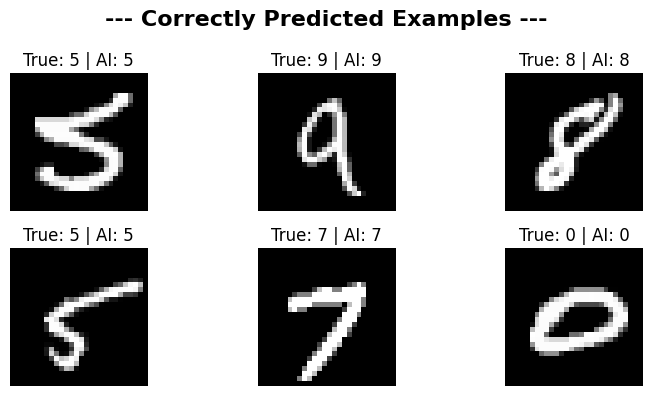

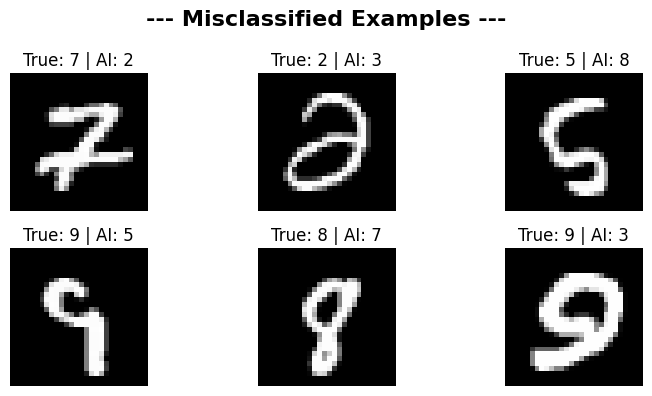

In [8]:
import matplotlib.pyplot as plt

def visualize_predictions(X, Y, predictions, show_correct=True, num_images=6):
    # Find indices where predictions match or don't match the true labels
    if show_correct:
        indices = np.where(predictions == Y)[0]
        title_prefix = "Correctly Predicted"
    else:
        indices = np.where(predictions != Y)[0]
        title_prefix = "Misclassified"

    # Pick a random selection from those indices
    random_indices = np.random.choice(indices, num_images, replace=False)

    # Set up a plotting grid
    plt.figure(figsize=(8, 4))

    for i, idx in enumerate(random_indices):
        plt.subplot(2, 3, i + 1)

        # Reshape the 784 column back into a 28x28 image grid for display
        # Remember X is shape (784, m), so X[:, idx] gets the 784 pixels for that image
        img = X[:, idx].reshape(28, 28)

        plt.imshow(img, cmap='gray')
        plt.title(f"True: {Y[idx]} | AI: {predictions[idx]}")
        plt.axis('off')

    plt.suptitle(f"--- {title_prefix} Examples ---", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the visualization functions!
visualize_predictions(X_test, Y_test, test_predictions, show_correct=True)
visualize_predictions(X_test, Y_test, test_predictions, show_correct=False)